# **Inverting Integrals**

The next code inverts the integral $F(u) = \int_1^u \frac{1}{x} \, dx $, without assuming that the integral can be evaluated as log function.

Epoch 1/500, Loss: 8.194771
Epoch 2/500, Loss: 5.862134
Epoch 3/500, Loss: 5.834973
Epoch 4/500, Loss: 5.926977
Epoch 5/500, Loss: 4.316354
Epoch 6/500, Loss: 2.767774
Epoch 7/500, Loss: 1.030171
Epoch 8/500, Loss: 0.725098
Epoch 9/500, Loss: 0.719769
Epoch 10/500, Loss: 0.594708
Epoch 11/500, Loss: 0.569783
Epoch 12/500, Loss: 0.422275
Epoch 13/500, Loss: 0.361594
Epoch 14/500, Loss: 0.368452
Epoch 15/500, Loss: 0.336536
Epoch 16/500, Loss: 0.301952
Epoch 17/500, Loss: 0.344594
Epoch 18/500, Loss: 0.235406
Epoch 19/500, Loss: 0.208651
Epoch 20/500, Loss: 0.200903
Epoch 21/500, Loss: 0.150889
Epoch 22/500, Loss: 0.136133
Epoch 23/500, Loss: 0.114724
Epoch 24/500, Loss: 0.126793
Epoch 25/500, Loss: 0.098287
Epoch 26/500, Loss: 0.079994
Epoch 27/500, Loss: 0.073284
Epoch 28/500, Loss: 0.078486
Epoch 29/500, Loss: 0.061666
Epoch 30/500, Loss: 0.059881
Epoch 31/500, Loss: 0.050103
Epoch 32/500, Loss: 0.050724
Epoch 33/500, Loss: 0.036621
Epoch 34/500, Loss: 0.054363
Epoch 35/500, Loss: 0.0

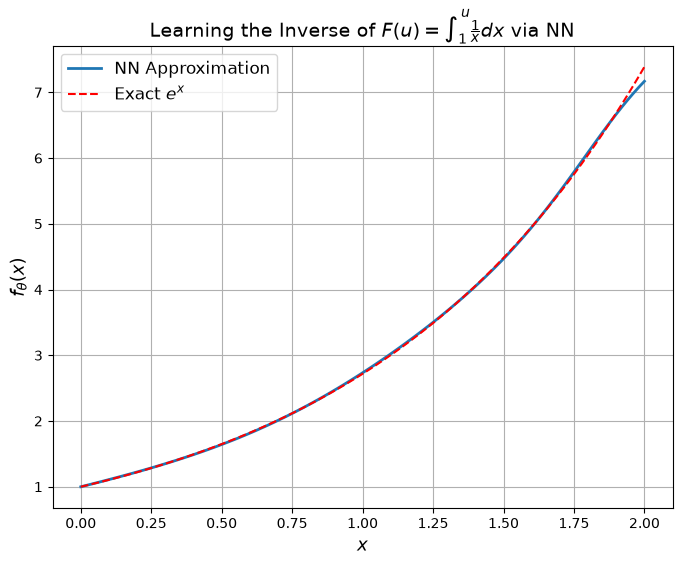

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Regularization weight for enforcing the initial condition
lambda_ic = 1.0

# Training data: u values in [0, 2]
x_train = np.linspace(0, 2, 100).reshape(-1, 1).astype(np.float32)
dummy_target = x_train.copy()

x_train = torch.tensor(x_train)
dummy_target = torch.tensor(dummy_target)

# Define the model: approximates the inverse function
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1)
        )

    def forward(self, x):
        return self.net(x)

model = Model()

# Vectorized numerical integral: ∫_1^{f_theta(u)} 1/x dx
def vectorized_integral(f_vals, num_points=100):
    a = 1.0
    b = torch.maximum(
        f_vals,
        torch.tensor(a + 1e-3, dtype=f_vals.dtype, device=f_vals.device)
    )  # ensure f_vals > 1

    s = torch.linspace(0.0, 1.0, num_points, device=f_vals.device)  # shape (num_points,)
    s = s.view(1, num_points)  # (1, M)
    b = b.view(-1, 1)          # (N, 1)

    # Broadcast to compute x values per sample
    x_vals = a + s * (b - a)  # shape (N, M)
    integrand = 1.0 / x_vals
    dx = (b - a) / num_points
    integral = torch.sum(integrand, dim=1, keepdim=True) * dx  # shape (N,1)
    return integral

# Custom loss using numerical integration
def custom_loss(y_true, y_pred):
    integral_vals = vectorized_integral(y_pred)
    equation_loss = torch.mean((integral_vals - y_true) ** 2)

    # Initial condition loss: f_theta(0) ≈ 1
    f0 = model(torch.tensor([[0.0]], dtype=torch.float32))
    ic_loss = (f0 - 1.0) ** 2

    return equation_loss + lambda_ic * ic_loss

# Compile and train the model
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 500
batch_size = 32

for epoch in range(epochs):
    permutation = torch.randperm(x_train.size(0))

    epoch_loss = 0.0

    for i in range(0, x_train.size(0), batch_size):
        indices = permutation[i:i + batch_size]

        batch_x = x_train[indices]
        batch_y = dummy_target[indices]

        optimizer.zero_grad()

        y_pred = model(batch_x)
        loss = custom_loss(batch_y, y_pred)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.6f}")

# Plot results
x_test = np.linspace(0, 2, 100).reshape(-1, 1).astype(np.float32)
x_test_tensor = torch.tensor(x_test)

with torch.no_grad():
    y_pred = model(x_test_tensor).numpy()

y_true = np.exp(x_test)

plt.figure(figsize=(8, 6))
plt.plot(x_test, y_pred, label="NN Approximation", linewidth=2)
plt.plot(x_test, y_true, label="Exact $e^x$", linestyle='dashed', color='red')
plt.title("Learning the Inverse of $F(u) = \\int_1^u \\frac{1}{x}dx$ via NN", fontsize=14)
plt.xlabel("$x$", fontsize=13)
plt.ylabel("$f_\\theta(x)$", fontsize=13)
plt.grid(True)
plt.legend(fontsize=12)
plt.show()

The next code uses neural nets to invert the integral $$ \int_0^{\cos \alpha(t)} \frac{dx}{\sqrt{x(1-x^2)}} =t. $$

Epoch [1/30] - Loss: 4.978446
Epoch [2/30] - Loss: 0.125043
Epoch [3/30] - Loss: 0.019962
Epoch [4/30] - Loss: 0.006626
Epoch [5/30] - Loss: 0.003353
Epoch [6/30] - Loss: 0.002224
Epoch [7/30] - Loss: 0.001723
Epoch [8/30] - Loss: 0.001474
Epoch [9/30] - Loss: 0.001335
Epoch [10/30] - Loss: 0.001255
Epoch [11/30] - Loss: 0.001182
Epoch [12/30] - Loss: 0.001136
Epoch [13/30] - Loss: 0.001082
Epoch [14/30] - Loss: 0.001043
Epoch [15/30] - Loss: 0.000998
Epoch [16/30] - Loss: 0.000958
Epoch [17/30] - Loss: 0.000927
Epoch [18/30] - Loss: 0.000883
Epoch [19/30] - Loss: 0.000850
Epoch [20/30] - Loss: 0.000813
Epoch [21/30] - Loss: 0.000781
Epoch [22/30] - Loss: 0.000746
Epoch [23/30] - Loss: 0.000717
Epoch [24/30] - Loss: 0.000685
Epoch [25/30] - Loss: 0.000657
Epoch [26/30] - Loss: 0.000628
Epoch [27/30] - Loss: 0.000608
Epoch [28/30] - Loss: 0.000579
Epoch [29/30] - Loss: 0.000556
Epoch [30/30] - Loss: 0.000534


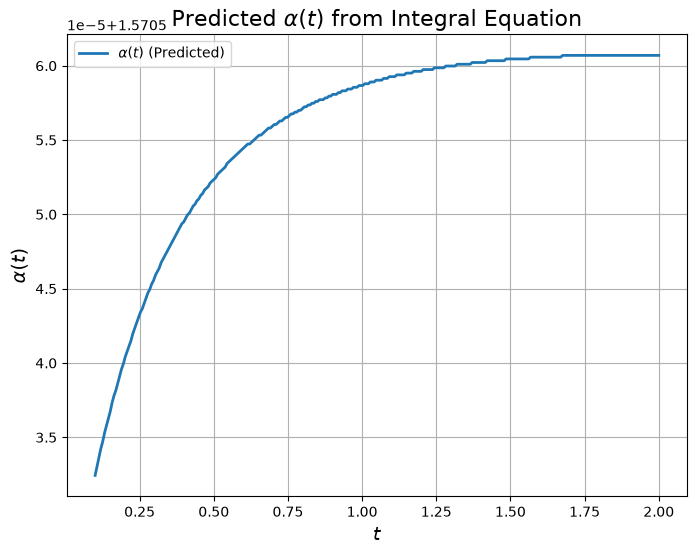

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(0)
torch.manual_seed(0)

# Riemann approximation parameters
num_points = 200
epsilon = 1e-4

# Define integrand safely
def integrand(x):
    return 1.0 / torch.sqrt(x * (1.0 - x**2) + epsilon)

# Vectorized Riemann approximation of integral ∫₀^cos(α(t)) 1/√(x(1 - x²)) dx
def approximate_integral_vectorized(cos_alpha_vals):
    integrals = []

    for upper in cos_alpha_vals:
        upper = torch.clamp(upper, epsilon, 1.0 - epsilon)
        x_vals = torch.linspace(epsilon, upper.item(), num_points, device=upper.device)
        dx = (upper - epsilon) / num_points
        integral = torch.sum(integrand(x_vals)) * dx
        integrals.append(integral)

    return torch.stack(integrals)

# Training data
t_train = np.linspace(0.1, 2.0, 200).reshape(-1, 1).astype(np.float32)
dummy_target = np.zeros_like(t_train)

t_train = torch.tensor(t_train)
dummy_target = torch.tensor(dummy_target)

# Define model
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(1, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1),
            nn.Sigmoid()  # Output in (0,1) ~ cos(alpha)
        )

    def forward(self, x):
        return self.network(x)

model = Model()

# Custom loss using Riemann integration
def custom_loss(y_true, y_pred):
    cos_alpha = y_pred.squeeze(1)
    integrals = approximate_integral_vectorized(cos_alpha)
    residual = integrals - y_true.squeeze(1)
    return torch.mean(residual ** 2)

# Compile and train
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 30
batch_size = 32

for epoch in range(epochs):
    permutation = torch.randperm(t_train.size(0))
    epoch_loss = 0.0

    for i in range(0, t_train.size(0), batch_size):
        indices = permutation[i:i + batch_size]
        batch_x = t_train[indices]
        batch_y = dummy_target[indices]

        optimizer.zero_grad()

        predictions = model(batch_x)
        loss = custom_loss(batch_y, predictions)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.6f}")

# Predict and plot
t_vals = np.linspace(0.1, 2.0, 300).reshape(-1, 1).astype(np.float32)
t_tensor = torch.tensor(t_vals)

with torch.no_grad():
    cos_alpha_pred = model(t_tensor).cpu().numpy()

alpha_pred = np.arccos(np.clip(cos_alpha_pred, 0, 1))

plt.figure(figsize=(8, 6))
plt.plot(t_vals, alpha_pred, label=r"$\alpha(t)$ (Predicted)", linewidth=2)
plt.title(r"Predicted $\alpha(t)$ from Integral Equation", fontsize=16)
plt.xlabel("$t$", fontsize=14)
plt.ylabel(r"$\alpha(t)$", fontsize=14)
plt.grid(True)
plt.legend()
plt.show()